# Notebook 05 – Clustering

**Objetivo:** Identificar grupos naturales en los datos GC-MS mediante clustering jerárquico y K-Means.

Se realizará:
- **Clustering de experimentos**: agrupar los 17 experimentos por similitud de perfil metabolómico.
- **Clustering de compuestos**: agrupar los 279 picos por patrones de expresión comunes entre experimentos.
- **Clustermap combinado**: visualización simultánea de ambos clusterings.

> **Nota:** Exp_9 fue identificado como outlier en notebooks 03 y 04. Se destacará en todas las visualizaciones.

## 1. Importaciones y rutas

In [1]:
# ── Importaciones ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
DATA_PROC = Path('../data/processed')
FIGS = Path('../results/figures')
FIGS.mkdir(parents=True, exist_ok=True)

print('✓ Librerías importadas')

✓ Librerías importadas


## 2. Carga de datos

In [2]:
# ── Carga de matrices preprocesadas ────────────────────────────────────────────
X_prep = pd.read_csv(DATA_PROC / 'X_preprocessed.csv')
X_log2_df = pd.read_csv(DATA_PROC / 'X_log2.csv')

# Ordenar columnas de experimentos numéricamente
exp_cols = sorted([c for c in X_prep.columns if c.startswith('Exp_')],
                  key=lambda x: int(x.split('_')[1].split('.')[0]))
exp_labels = [c.replace('.CDF', '') for c in exp_cols]
meta_cols  = ['compound_name', 'hit_match_factor', 'match_quality', 'retention_time']

# Matrices numpy
X      = X_prep[exp_cols].values        # 279 × 17  (RobustScaler)
X_log2 = X_log2_df[exp_cols].values     # 279 × 17  (log2, sin escalar)
compounds = X_prep['compound_name'].values

# Transpuestas para clustering de experimentos
X_exp      = X.T        # 17 × 279
X_exp_log2 = X_log2.T   # 17 × 279

# Índice del outlier Exp_9
OUTLIER_IDX = exp_labels.index('Exp_9')

print('=' * 60)
print('DATOS CARGADOS')
print('=' * 60)
print(f'Picos (filas):        {X.shape[0]}')
print(f'Experimentos (cols):  {X.shape[1]}')
print(f'Compuestos únicos:    {X_prep["compound_name"].nunique()}')
print(f'Outlier conocido:     Exp_9 (índice {OUTLIER_IDX})')

DATOS CARGADOS
Picos (filas):        279
Experimentos (cols):  17
Compuestos únicos:    143
Outlier conocido:     Exp_9 (índice 8)


## 3. Clustering jerárquico de experimentos

Se aplica **clustering jerárquico con método Ward** sobre los 17 experimentos usando sus perfiles de 279 picos (matriz escalada). El dendrograma muestra visualmente qué experimentos tienen perfiles más similares entre sí.

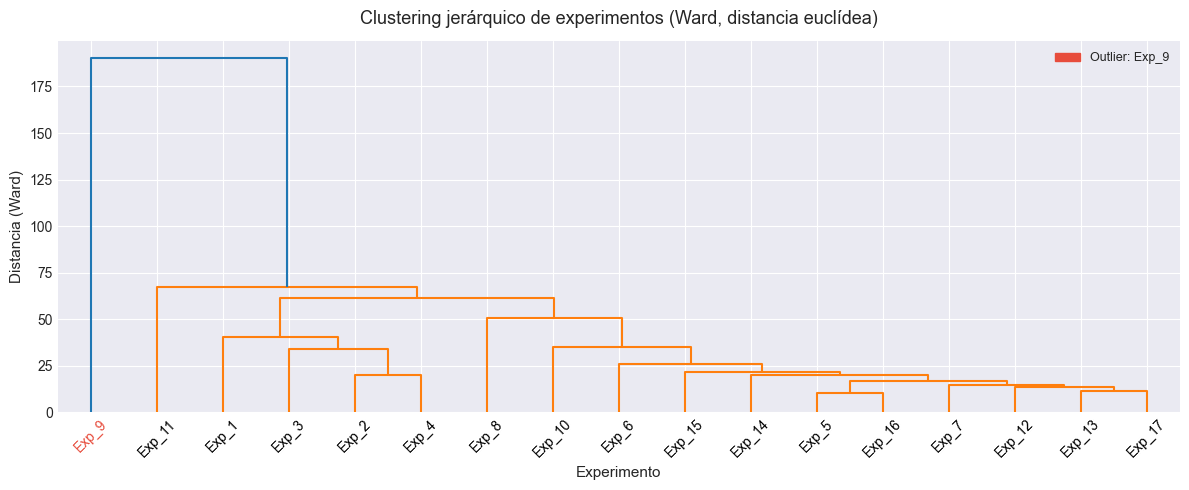

✓ Figura guardada: results/figures/05_dendrogram_experiments.png


In [3]:
# ── Clustering jerárquico de experimentos ──────────────────────────────────────
# Usamos la matriz escalada (RobustScaler) — 17 experimentos × 279 picos
linkage_exp = linkage(X_exp, method='ward', metric='euclidean')

# Colores de etiquetas: Exp_9 en rojo
label_colors = ['#e74c3c' if lab == 'Exp_9' else 'black' for lab in exp_labels]

fig, ax = plt.subplots(figsize=(12, 5))

dend = dendrogram(
    linkage_exp,
    labels=exp_labels,
    ax=ax,
    leaf_rotation=45,
    leaf_font_size=10,
    color_threshold=0.7 * max(linkage_exp[:, 2])   # umbral automático al 70%
)

# Colorear etiquetas del eje X
xlabels = ax.get_xmajorticklabels()
for lbl in xlabels:
    lbl.set_color('#e74c3c' if lbl.get_text() == 'Exp_9' else 'black')

ax.set_title('Clustering jerárquico de experimentos (Ward, distancia euclídea)', fontsize=13, pad=12)
ax.set_xlabel('Experimento', fontsize=11)
ax.set_ylabel('Distancia (Ward)', fontsize=11)

outlier_patch = mpatches.Patch(color='#e74c3c', label='Outlier: Exp_9')
ax.legend(handles=[outlier_patch], fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig(FIGS / '05_dendrogram_experiments.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Figura guardada: results/figures/05_dendrogram_experiments.png')

## 4. K-Means en experimentos

Se busca el número óptimo de clusters para los experimentos evaluando:
- **Inercia (elbow)**: suma de distancias al centroide — decrece con K, buscamos el "codo".
- **Silhouette score**: mide la cohesión y separación de clusters (más alto = mejor).

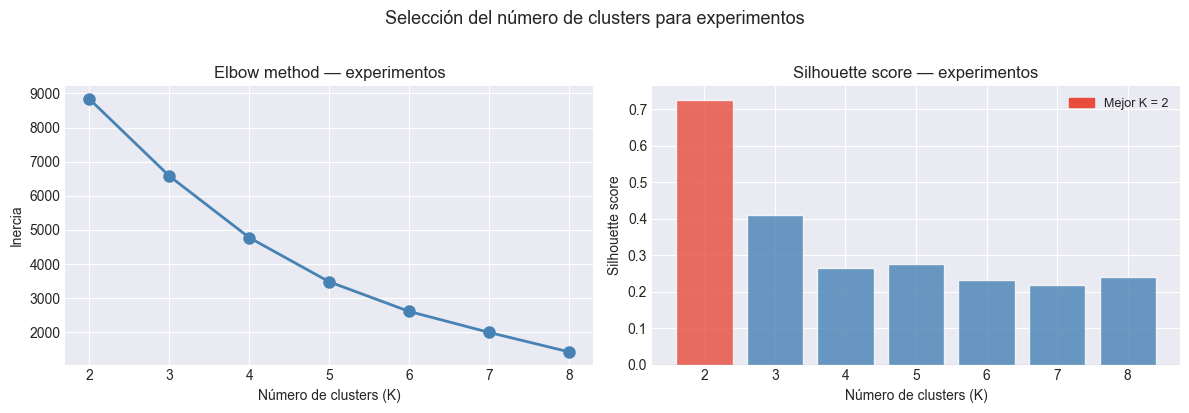


Resultados silhouette por K:
  K=2: silhouette = 0.7270  ← mejor
  K=3: silhouette = 0.4101
  K=4: silhouette = 0.2642
  K=5: silhouette = 0.2762
  K=6: silhouette = 0.2323
  K=7: silhouette = 0.2171
  K=8: silhouette = 0.2397

✓ K óptimo sugerido para experimentos: 2


In [4]:
# ── Elbow + Silhouette para experimentos ───────────────────────────────────────
# Rango de K: 2 a 8 (máximo sensato con 17 experimentos)
K_range = range(2, 9)
inertias   = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_k = km.fit_predict(X_exp)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_exp, labels_k)
    silhouettes.append(sil)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Elbow
ax1.plot(list(K_range), inertias, 'o-', color='steelblue', linewidth=2, markersize=8)
ax1.set_title('Elbow method — experimentos', fontsize=12)
ax1.set_xlabel('Número de clusters (K)', fontsize=10)
ax1.set_ylabel('Inercia', fontsize=10)
ax1.set_xticks(list(K_range))

# Silhouette
best_k_exp = list(K_range)[np.argmax(silhouettes)]
bar_colors = ['#e74c3c' if k == best_k_exp else 'steelblue' for k in K_range]
ax2.bar(list(K_range), silhouettes, color=bar_colors, alpha=0.8, edgecolor='white')
ax2.set_title('Silhouette score — experimentos', fontsize=12)
ax2.set_xlabel('Número de clusters (K)', fontsize=10)
ax2.set_ylabel('Silhouette score', fontsize=10)
ax2.set_xticks(list(K_range))
ax2.axhline(0, color='black', linewidth=0.8, alpha=0.5)

best_patch = mpatches.Patch(color='#e74c3c', label=f'Mejor K = {best_k_exp}')
ax2.legend(handles=[best_patch], fontsize=9)

plt.suptitle('Selección del número de clusters para experimentos', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGS / '05_elbow_experiments.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'\nResultados silhouette por K:')
for k, s in zip(K_range, silhouettes):
    marker = '  ← mejor' if k == best_k_exp else ''
    print(f'  K={k}: silhouette = {s:.4f}{marker}')
print(f'\n✓ K óptimo sugerido para experimentos: {best_k_exp}')

## 5. Asignación de clusters a experimentos

Se aplica K-Means con el K óptimo identificado. Los clusters se inspeccionan para entender qué experimentos quedan agrupados juntos y si Exp_9 forma su propio cluster.

CLUSTERING DE EXPERIMENTOS — K = 2

  Cluster 1:
    · Exp_1
    · Exp_2
    · Exp_3
    · Exp_4
    · Exp_5
    · Exp_6
    · Exp_7
    · Exp_8
    · Exp_10
    · Exp_11
    · Exp_12
    · Exp_13
    · Exp_14
    · Exp_15
    · Exp_16
    · Exp_17

  Cluster 2: ⚠ contiene Exp_9
    · Exp_9  ← outlier


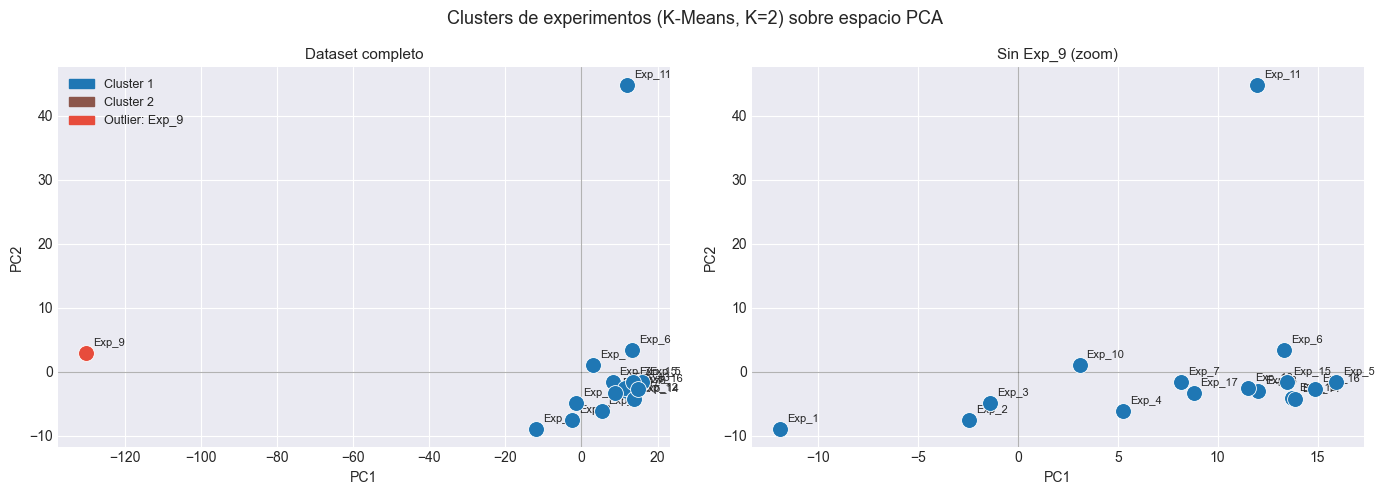

✓ Figura guardada: results/figures/05_clusters_experiments_pca.png


In [5]:
# ── K-Means experimentos con K óptimo ─────────────────────────────────────────
K_EXP = best_k_exp   # K seleccionado automáticamente

km_exp = KMeans(n_clusters=K_EXP, random_state=42, n_init=20)
exp_cluster_labels = km_exp.fit_predict(X_exp)

# Crear DataFrame de resultados
exp_clusters_df = pd.DataFrame({
    'experiment'  : exp_labels,
    'cluster'     : exp_cluster_labels,
    'is_outlier'  : [lab == 'Exp_9' for lab in exp_labels]
})

print('=' * 55)
print(f'CLUSTERING DE EXPERIMENTOS — K = {K_EXP}')
print('=' * 55)

cluster_colors = plt.cm.tab10(np.linspace(0, 0.5, K_EXP))

for c in sorted(exp_clusters_df['cluster'].unique()):
    members = exp_clusters_df[exp_clusters_df['cluster'] == c]['experiment'].tolist()
    outlier_flag = ' ⚠ contiene Exp_9' if 'Exp_9' in members else ''
    print(f'\n  Cluster {c+1}:{outlier_flag}')
    for m in members:
        marker = '  ← outlier' if m == 'Exp_9' else ''
        print(f'    · {m}{marker}')

# Visualización: scatter PCA con color de cluster
pca_df = pd.read_csv(DATA_PROC / 'pca_experiments.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Clusters de experimentos (K-Means, K={K_EXP}) sobre espacio PCA', fontsize=13)

for ax_idx, (ax, title, exclude) in enumerate([
    (axes[0], 'Dataset completo', []),
    (axes[1], 'Sin Exp_9 (zoom)', ['Exp_9'])
]):
    subset = pca_df[~pca_df['experiment'].isin(exclude)]
    for _, row in subset.iterrows():
        c = exp_clusters_df.loc[exp_clusters_df['experiment'] == row['experiment'], 'cluster'].values[0]
        color = '#e74c3c' if row['experiment'] == 'Exp_9' else cluster_colors[c]
        ax.scatter(row['PC1'], row['PC2'], c=[color], s=130, zorder=5,
                   edgecolors='white', linewidths=0.6)
        ax.annotate(row['experiment'], (row['PC1'], row['PC2']),
                    xytext=(5, 5), textcoords='offset points', fontsize=8)
    ax.axhline(0, color='black', alpha=0.3, linewidth=0.8)
    ax.axvline(0, color='black', alpha=0.3, linewidth=0.8)
    ax.set_xlabel('PC1', fontsize=10)
    ax.set_ylabel('PC2', fontsize=10)
    ax.set_title(title, fontsize=11)

# Leyenda clusters
handles = [mpatches.Patch(color=cluster_colors[c], label=f'Cluster {c+1}') for c in range(K_EXP)]
handles.append(mpatches.Patch(color='#e74c3c', label='Outlier: Exp_9'))
axes[0].legend(handles=handles, fontsize=9, loc='best')

plt.tight_layout()
plt.savefig(FIGS / '05_clusters_experiments_pca.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Figura guardada: results/figures/05_clusters_experiments_pca.png')

## 6. K-Means en compuestos — elbow + silhouette

Se busca el número óptimo de clusters para agrupar los **279 picos cromatográficos** según su patrón de intensidad a través de los 17 experimentos. Compuestos con perfiles similares pueden compartir rutas metabólicas o responder al mismo factor biológico.

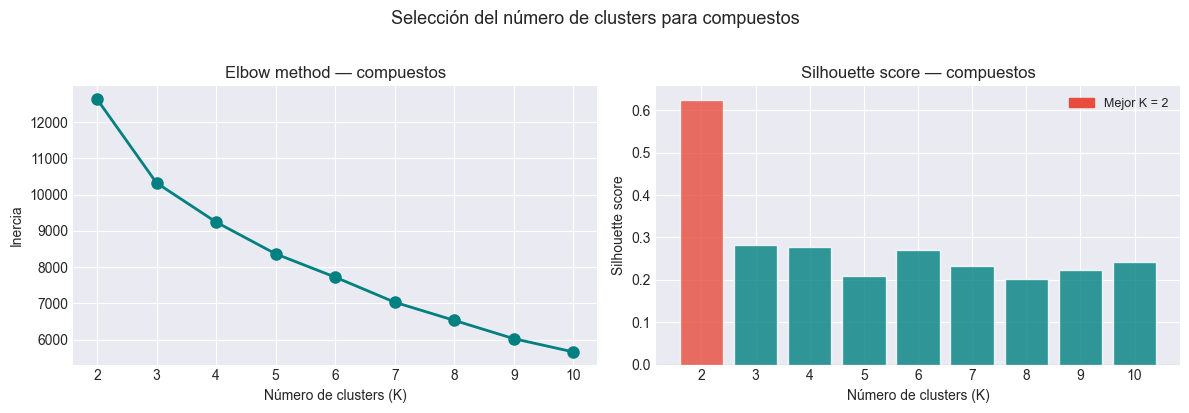


Resultados silhouette por K:
  K=2: silhouette = 0.6251  ← mejor
  K=3: silhouette = 0.2828
  K=4: silhouette = 0.2781
  K=5: silhouette = 0.2092
  K=6: silhouette = 0.2711
  K=7: silhouette = 0.2317
  K=8: silhouette = 0.2021
  K=9: silhouette = 0.2242
  K=10: silhouette = 0.2428

✓ K óptimo sugerido para compuestos: 2


In [6]:
# ── Elbow + Silhouette para compuestos ─────────────────────────────────────────
# Rango K: 2 a 10 (más opciones para 279 compuestos)
K_range_cpd = range(2, 11)
inertias_cpd   = []
silhouettes_cpd = []

for k in K_range_cpd:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_k = km.fit_predict(X)   # X: 279 × 17 (RobustScaler)
    inertias_cpd.append(km.inertia_)
    sil = silhouette_score(X, labels_k)
    silhouettes_cpd.append(sil)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Elbow
ax1.plot(list(K_range_cpd), inertias_cpd, 'o-', color='teal', linewidth=2, markersize=8)
ax1.set_title('Elbow method — compuestos', fontsize=12)
ax1.set_xlabel('Número de clusters (K)', fontsize=10)
ax1.set_ylabel('Inercia', fontsize=10)
ax1.set_xticks(list(K_range_cpd))

# Silhouette
best_k_cpd = list(K_range_cpd)[np.argmax(silhouettes_cpd)]
bar_colors = ['#e74c3c' if k == best_k_cpd else 'teal' for k in K_range_cpd]
ax2.bar(list(K_range_cpd), silhouettes_cpd, color=bar_colors, alpha=0.8, edgecolor='white')
ax2.set_title('Silhouette score — compuestos', fontsize=12)
ax2.set_xlabel('Número de clusters (K)', fontsize=10)
ax2.set_ylabel('Silhouette score', fontsize=10)
ax2.set_xticks(list(K_range_cpd))
ax2.axhline(0, color='black', linewidth=0.8, alpha=0.5)

best_patch = mpatches.Patch(color='#e74c3c', label=f'Mejor K = {best_k_cpd}')
ax2.legend(handles=[best_patch], fontsize=9)

plt.suptitle('Selección del número de clusters para compuestos', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGS / '05_elbow_compounds.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'\nResultados silhouette por K:')
for k, s in zip(K_range_cpd, silhouettes_cpd):
    marker = '  ← mejor' if k == best_k_cpd else ''
    print(f'  K={k}: silhouette = {s:.4f}{marker}')
print(f'\n✓ K óptimo sugerido para compuestos: {best_k_cpd}')

## 7. Asignación de clusters a compuestos

Se aplica K-Means con el K óptimo. Para cada cluster se muestra el tamaño, el perfil medio de intensidad (log₂) a través de los experimentos, y los compuestos con mayor varianza dentro del cluster (los más "representativos").

CLUSTERING DE COMPUESTOS — K = 2

  Cluster 1: 22 compuestos
    · Bicyclo[3.1.1]heptane, 6,6-dimethyl-2-methylene-, (1S)-
    · Cyclohexene, 4-methylene-1-(1-methylethyl)-
    · 1,3-Dioxolane
    · 2-Butanone
    · 2-Butanone

  Cluster 2: 257 compuestos
    · 1,3,5-Cycloheptatriene, 3,7,7-trimethyl-
    · 2-Propenal
    · Tolycaine
    · Hexanal
    · 2-Butanone


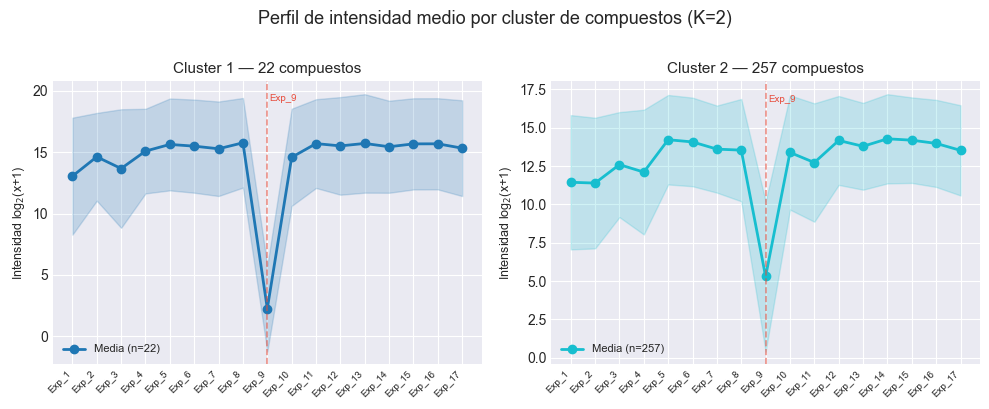

✓ Figura guardada: results/figures/05_cluster_profiles.png


In [7]:
# ── K-Means compuestos con K óptimo ───────────────────────────────────────────
K_CPD = best_k_cpd

km_cpd = KMeans(n_clusters=K_CPD, random_state=42, n_init=20)
cpd_cluster_labels = km_cpd.fit_predict(X)

# DataFrame de compuestos con cluster asignado
compound_clusters_df = X_prep[meta_cols].copy()
compound_clusters_df['cluster'] = cpd_cluster_labels

print('=' * 60)
print(f'CLUSTERING DE COMPUESTOS — K = {K_CPD}')
print('=' * 60)

for c in sorted(compound_clusters_df['cluster'].unique()):
    members = compound_clusters_df[compound_clusters_df['cluster'] == c]
    print(f'\n  Cluster {c+1}: {len(members)} compuestos')
    # Top 5 por mayor varianza en ese cluster
    cluster_X = X[compound_clusters_df['cluster'].values == c]
    variances  = np.var(cluster_X, axis=1)
    top_idx    = np.argsort(variances)[::-1][:5]
    top_names  = members['compound_name'].values[top_idx]
    for name in top_names:
        print(f'    · {name}')

# ── Perfiles medios por cluster (intensidad log2) ─────────────────────────────
n_cols = min(K_CPD, 3)
n_rows = (K_CPD + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes_flat = np.array(axes).flatten() if K_CPD > 1 else [axes]

cluster_palette = plt.cm.tab10(np.linspace(0, 0.9, K_CPD))

for c in range(K_CPD):
    ax = axes_flat[c]
    mask = cpd_cluster_labels == c
    # Perfil medio del cluster (log2)
    profile_mean = X_log2[mask].mean(axis=0)
    profile_std  = X_log2[mask].std(axis=0)
    x_pos = range(len(exp_labels))

    ax.fill_between(x_pos,
                    profile_mean - profile_std,
                    profile_mean + profile_std,
                    alpha=0.2, color=cluster_palette[c])
    ax.plot(x_pos, profile_mean, 'o-', color=cluster_palette[c],
            linewidth=2, markersize=6, label=f'Media (n={mask.sum()})')

    # Marcar Exp_9
    ax.axvline(OUTLIER_IDX, color='#e74c3c', linestyle='--', alpha=0.6, linewidth=1.2)
    ax.text(OUTLIER_IDX + 0.1, ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] != 0 else 1,
            'Exp_9', color='#e74c3c', fontsize=7, va='top')

    ax.set_xticks(list(x_pos))
    ax.set_xticklabels(exp_labels, rotation=45, ha='right', fontsize=7)
    ax.set_title(f'Cluster {c+1} — {mask.sum()} compuestos', fontsize=11)
    ax.set_ylabel('Intensidad log$_2$(x+1)', fontsize=9)
    ax.legend(fontsize=8)

# Ocultar ejes sobrantes
for i in range(K_CPD, len(axes_flat)):
    axes_flat[i].axis('off')

plt.suptitle(f'Perfil de intensidad medio por cluster de compuestos (K={K_CPD})',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGS / '05_cluster_profiles.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Figura guardada: results/figures/05_cluster_profiles.png')

## 8. Clustermap combinado

El **clustermap** de seaborn aplica clustering jerárquico simultáneamente en filas (compuestos) y columnas (experimentos), reorganizando la matriz para que los grupos similares queden adyacentes. Se visualizan los **top 60 compuestos con mayor varianza** para mayor legibilidad.

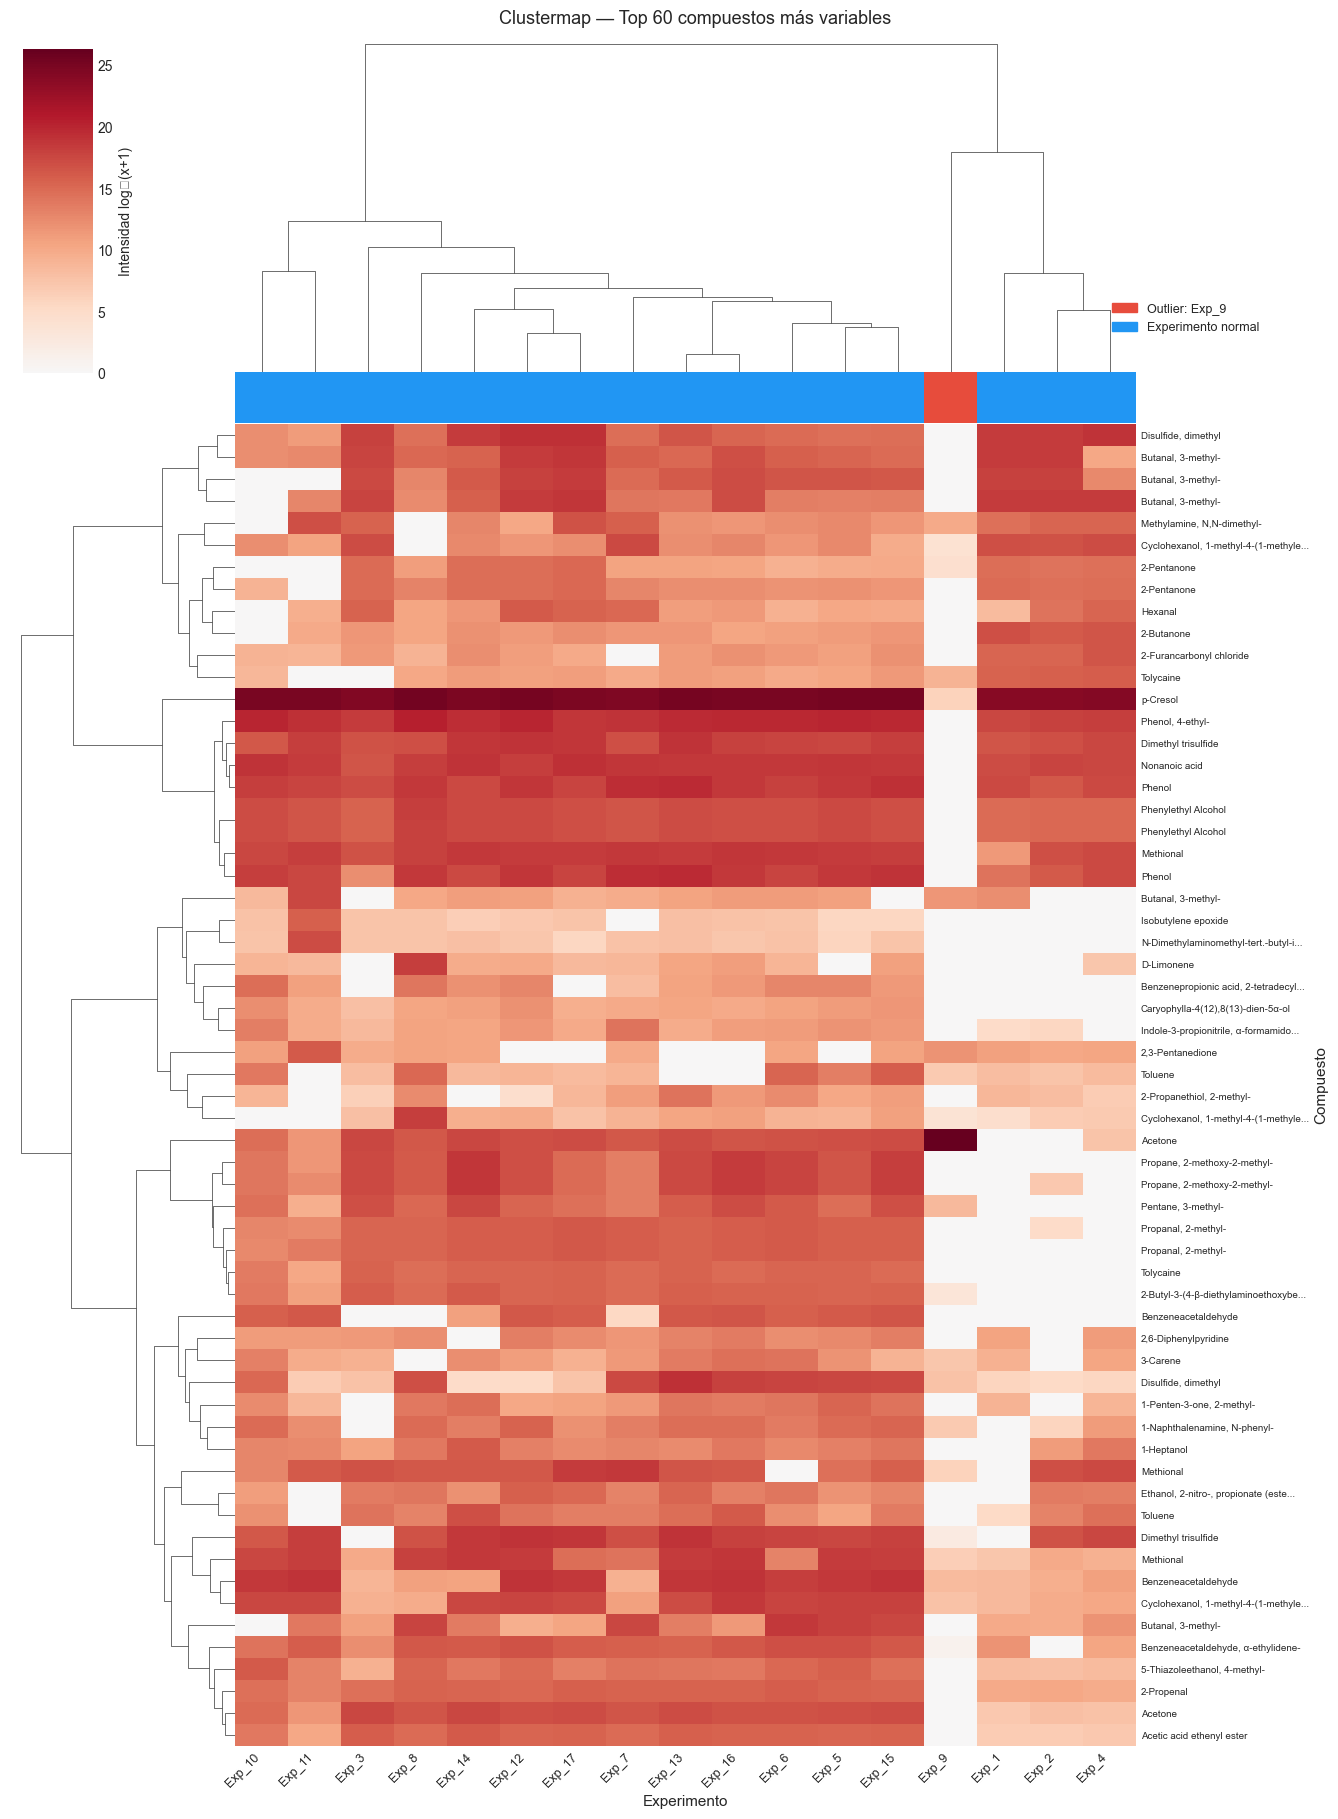

✓ Figura guardada: results/figures/05_clustermap.png


In [8]:
# ── Clustermap: top 60 compuestos más variables ────────────────────────────────
# Seleccionar top 60 por varianza (sobre X_log2)
variances_all = np.var(X_log2, axis=1)
top60_idx = np.argsort(variances_all)[::-1][:60]

X_top60     = X_log2[top60_idx]          # 60 × 17
names_top60 = compounds[top60_idx]

# Truncar nombres largos
names_short = [n[:35] + '...' if len(n) > 35 else n for n in names_top60]

df_top60 = pd.DataFrame(X_top60, index=names_short, columns=exp_labels)

# Colores de columna: Exp_9 en rojo
col_colors = ['#e74c3c' if lab == 'Exp_9' else '#2196F3' for lab in exp_labels]

g = sns.clustermap(
    df_top60,
    method='ward',
    metric='euclidean',
    cmap='RdBu_r',
    center=0,
    col_colors=col_colors,
    linewidths=0.0,
    figsize=(14, 18),
    xticklabels=True,
    yticklabels=True,
    cbar_kws={'label': 'Intensidad log₂(x+1)'}
)

g.ax_heatmap.set_xlabel('Experimento', fontsize=11)
g.ax_heatmap.set_ylabel('Compuesto', fontsize=11)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=9)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=7)
g.figure.suptitle('Clustermap — Top 60 compuestos más variables', fontsize=13, y=1.002)

# Leyenda manual
legend_elements = [
    mpatches.Patch(color='#e74c3c', label='Outlier: Exp_9'),
    mpatches.Patch(color='#2196F3', label='Experimento normal')
]
g.ax_heatmap.legend(handles=legend_elements, bbox_to_anchor=(1.15, 1.1),
                    loc='upper right', fontsize=9)

plt.savefig(FIGS / '05_clustermap.png', dpi=200, bbox_inches='tight')
plt.show()
print('✓ Figura guardada: results/figures/05_clustermap.png')

## 9. Guardar resultados

In [9]:
# ── Guardar asignaciones de clusters ──────────────────────────────────────────

# Experimentos
exp_clusters_df.to_csv(DATA_PROC / 'experiment_clusters.csv', index=False)

# Compuestos: añadir intensidades log2 para referencia
X_log2_out = pd.DataFrame(X_log2, columns=exp_cols)
compound_clusters_full = pd.concat(
    [compound_clusters_df.reset_index(drop=True), X_log2_out.reset_index(drop=True)],
    axis=1
)
compound_clusters_full.to_csv(DATA_PROC / 'compound_clusters.csv', index=False)

print('=' * 60)
print('ARCHIVOS GUARDADOS')
print('=' * 60)
print(f'\n✓ data/processed/experiment_clusters.csv')
print(f'   {exp_clusters_df.shape[0]} experimentos × {exp_clusters_df.shape[1]} columnas')
print(f'\n✓ data/processed/compound_clusters.csv')
print(f'   {compound_clusters_full.shape[0]} compuestos × {compound_clusters_full.shape[1]} columnas')
print(f'\nFiguras:')
print(f'  · 05_dendrogram_experiments.png')
print(f'  · 05_elbow_experiments.png')
print(f'  · 05_clusters_experiments_pca.png')
print(f'  · 05_elbow_compounds.png')
print(f'  · 05_cluster_profiles.png')
print(f'  · 05_clustermap.png')

ARCHIVOS GUARDADOS

✓ data/processed/experiment_clusters.csv
   17 experimentos × 3 columnas

✓ data/processed/compound_clusters.csv
   279 compuestos × 22 columnas

Figuras:
  · 05_dendrogram_experiments.png
  · 05_elbow_experiments.png
  · 05_clusters_experiments_pca.png
  · 05_elbow_compounds.png
  · 05_cluster_profiles.png
  · 05_clustermap.png


## 10. Resumen

In [10]:
# ── Resumen de resultados ──────────────────────────────────────────────────────
sil_exp = silhouette_score(X_exp, exp_cluster_labels)
sil_cpd = silhouette_score(X,     cpd_cluster_labels)

print('=' * 65)
print('RESUMEN — CLUSTERING (Notebook 05)')
print('=' * 65)
print(f'\nMATRIZ ANALIZADA')
print(f'  Picos: {X.shape[0]}   Experimentos: {X.shape[1]}')

print(f'\nCLUSTERING DE EXPERIMENTOS (K-Means)')
print(f'  K óptimo            : {K_EXP}')
print(f'  Silhouette score    : {sil_exp:.4f}')
for c in range(K_EXP):
    members = exp_clusters_df[exp_clusters_df['cluster'] == c]['experiment'].tolist()
    print(f'  Cluster {c+1} ({len(members)} exp.)  : {members}')

print(f'\nCLUSTERING DE COMPUESTOS (K-Means)')
print(f'  K óptimo            : {K_CPD}')
print(f'  Silhouette score    : {sil_cpd:.4f}')
for c in range(K_CPD):
    n = (cpd_cluster_labels == c).sum()
    print(f'  Cluster {c+1}           : {n} compuestos')

print('=' * 65)

RESUMEN — CLUSTERING (Notebook 05)

MATRIZ ANALIZADA
  Picos: 279   Experimentos: 17

CLUSTERING DE EXPERIMENTOS (K-Means)
  K óptimo            : 2
  Silhouette score    : 0.7270
  Cluster 1 (16 exp.)  : ['Exp_1', 'Exp_2', 'Exp_3', 'Exp_4', 'Exp_5', 'Exp_6', 'Exp_7', 'Exp_8', 'Exp_10', 'Exp_11', 'Exp_12', 'Exp_13', 'Exp_14', 'Exp_15', 'Exp_16', 'Exp_17']
  Cluster 2 (1 exp.)  : ['Exp_9']

CLUSTERING DE COMPUESTOS (K-Means)
  K óptimo            : 2
  Silhouette score    : 0.6251
  Cluster 1           : 22 compuestos
  Cluster 2           : 257 compuestos


## Conclusiones

El análisis de clustering realizado sobre el conjunto completo muestra que la estructura global del dataset está fuertemente condicionada por la presencia de muestras atípicas, especialmente Exp_9. En este contexto, la separación observada entre clusters parece reflejar principalmente el comportamiento diferencial de este experimento respecto al resto, más que la existencia de subgrupos internos bien definidos dentro del conjunto principal de muestras.

## 11. Clustering refinado excluyendo los outliers Exp_9 y Exp_11

### Análisis exploratorio de la subestructura del grupo principal

> **Nota:** Este análisis se realiza **exclusivamente con fines exploratorios**.  
> El objetivo no es redefinir los resultados del clustering original, sino examinar si existe  
> alguna subestructura dentro del grupo principal de experimentos **una vez eliminado el efecto  
> dominante de Exp_9 y Exp_11**. Se excluyen ambos experimentos para estudiar la posible  
> organización interna de los 15 experimentos restantes.

In [18]:
# ── Paso 1: Dataset sin Exp_9 ni Exp_11 ──────────────────────────────────────
# X_exp es 17×279 (experimentos como filas).
# Se filtran las filas de Exp_9 y Exp_11, dejando 15 experimentos.

OUTLIERS_NO = ['Exp_9', 'Exp_11']

mask_no_out = [i for i, lab in enumerate(exp_labels) if lab not in OUTLIERS_NO]
exp_labels_no_out = [exp_labels[i] for i in mask_no_out]

X_no_outlier  = X_exp[mask_no_out]       # 15 × 279  (RobustScaler)
X_log2_no_out = X_log2[:, mask_no_out]   # 279 × 15  (log2, para clustermap)

print('=' * 55)
print('DATASET SIN EXP_9 NI EXP_11')
print('=' * 55)
print(f'X_no_outlier shape : {X_no_outlier.shape}  (experimentos × picos)')
print(f'Experimentos incluidos ({len(exp_labels_no_out)}):')
for lab in exp_labels_no_out:
    print(f'  · {lab}')

DATASET SIN EXP_9 NI EXP_11
X_no_outlier shape : (15, 279)  (experimentos × picos)
Experimentos incluidos (15):
  · Exp_1
  · Exp_2
  · Exp_3
  · Exp_4
  · Exp_5
  · Exp_6
  · Exp_7
  · Exp_8
  · Exp_10
  · Exp_12
  · Exp_13
  · Exp_14
  · Exp_15
  · Exp_16
  · Exp_17


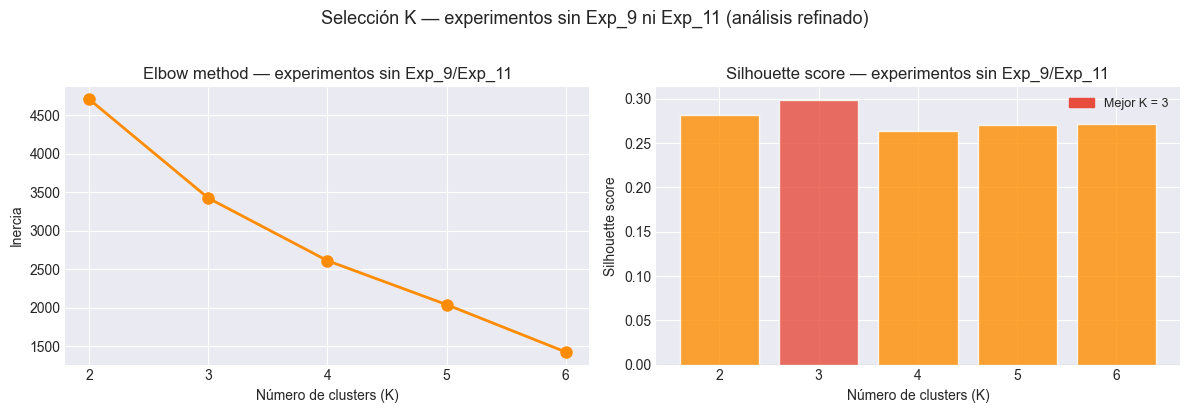

Silhouette por K (sin Exp_9 ni Exp_11):
  K=2: silhouette = 0.2821
  K=3: silhouette = 0.2988  ← mejor
  K=4: silhouette = 0.2632
  K=5: silhouette = 0.2700
  K=6: silhouette = 0.2717

K óptimo (sin Exp_9 ni Exp_11): 3
✓ Figura guardada: results/figures/05_elbow_no_outlier.png


In [19]:
# ── Paso 2: Selección K óptimo sin Exp_9 ni Exp_11 ───────────────────────────
# Se evalúan K = 2 a 6, acorde al tamaño del subconjunto (15 experimentos).

K_range_no_out     = range(2, 7)
inertias_no_out    = []
silhouettes_no_out = []

for k in K_range_no_out:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_k = km.fit_predict(X_no_outlier)
    inertias_no_out.append(km.inertia_)
    sil = silhouette_score(X_no_outlier, labels_k)
    silhouettes_no_out.append(sil)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Elbow
ax1.plot(list(K_range_no_out), inertias_no_out, 'o-', color='darkorange',
         linewidth=2, markersize=8)
ax1.set_title('Elbow method — experimentos sin Exp_9/Exp_11', fontsize=12)
ax1.set_xlabel('Número de clusters (K)', fontsize=10)
ax1.set_ylabel('Inercia', fontsize=10)
ax1.set_xticks(list(K_range_no_out))

# Silhouette
best_k_no_out = list(K_range_no_out)[np.argmax(silhouettes_no_out)]
bar_colors_no_out = ['#e74c3c' if k == best_k_no_out else 'darkorange'
                     for k in K_range_no_out]
ax2.bar(list(K_range_no_out), silhouettes_no_out,
        color=bar_colors_no_out, alpha=0.8, edgecolor='white')
ax2.set_title('Silhouette score — experimentos sin Exp_9/Exp_11', fontsize=12)
ax2.set_xlabel('Número de clusters (K)', fontsize=10)
ax2.set_ylabel('Silhouette score', fontsize=10)
ax2.set_xticks(list(K_range_no_out))
ax2.axhline(0, color='black', linewidth=0.8, alpha=0.5)

best_patch_no_out = mpatches.Patch(color='#e74c3c', label=f'Mejor K = {best_k_no_out}')
ax2.legend(handles=[best_patch_no_out], fontsize=9)

plt.suptitle('Selección K — experimentos sin Exp_9 ni Exp_11 (análisis refinado)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGS / '05_elbow_no_outlier.png', dpi=300, bbox_inches='tight')
plt.show()

print('Silhouette por K (sin Exp_9 ni Exp_11):')
for k, s in zip(K_range_no_out, silhouettes_no_out):
    marker = '  ← mejor' if k == best_k_no_out else ''
    print(f'  K={k}: silhouette = {s:.4f}{marker}')
print(f'\nK óptimo (sin Exp_9 ni Exp_11): {best_k_no_out}')
print('✓ Figura guardada: results/figures/05_elbow_no_outlier.png')

In [20]:
# ── Paso 3: K-Means en dataset sin Exp_9 ni Exp_11 ───────────────────────────
K_NO_OUT = best_k_no_out

km_no_out     = KMeans(n_clusters=K_NO_OUT, random_state=42, n_init=20)
labels_no_out = km_no_out.fit_predict(X_no_outlier)

exp_clusters_no_out_df = pd.DataFrame({
    'experiment': exp_labels_no_out,
    'cluster'   : labels_no_out
})

sil_no_out = silhouette_score(X_no_outlier, labels_no_out)

print('=' * 55)
print(f'CLUSTERING SIN EXP_9 NI EXP_11 — K = {K_NO_OUT}')
print('=' * 55)
print(f'Silhouette score: {sil_no_out:.4f}')
print()

for c in sorted(exp_clusters_no_out_df['cluster'].unique()):
    members = exp_clusters_no_out_df[exp_clusters_no_out_df['cluster'] == c]
    print(f'  Cluster {c+1} ({len(members)} experimentos):')
    for _, row in members.iterrows():
        print(f'    · {row["experiment"]}')
    print()

print('Tabla completa:')
print(exp_clusters_no_out_df.to_string(index=False))

CLUSTERING SIN EXP_9 NI EXP_11 — K = 3
Silhouette score: 0.2988

  Cluster 1 (4 experimentos):
    · Exp_1
    · Exp_2
    · Exp_3
    · Exp_4

  Cluster 2 (10 experimentos):
    · Exp_5
    · Exp_6
    · Exp_7
    · Exp_10
    · Exp_12
    · Exp_13
    · Exp_14
    · Exp_15
    · Exp_16
    · Exp_17

  Cluster 3 (1 experimentos):
    · Exp_8

Tabla completa:
experiment  cluster
     Exp_1        0
     Exp_2        0
     Exp_3        0
     Exp_4        0
     Exp_5        1
     Exp_6        1
     Exp_7        1
     Exp_8        2
    Exp_10        1
    Exp_12        1
    Exp_13        1
    Exp_14        1
    Exp_15        1
    Exp_16        1
    Exp_17        1


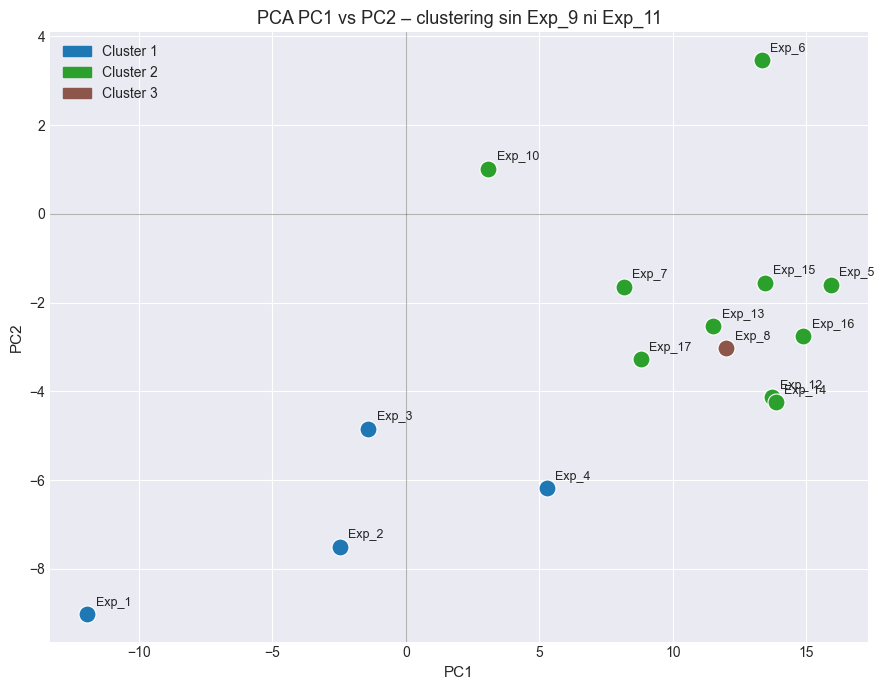

✓ Figura guardada: results/figures/05_pca_no_outlier.png


In [21]:
# ── Paso 4: Visualización PCA — PC1 vs PC2 sin Exp_9 ni Exp_11 ───────────────
# Se reutilizan los scores PCA ya calculados en este notebook.
pca_no_out = pca_df[~pca_df['experiment'].isin(OUTLIERS_NO)].copy().reset_index(drop=True)

cluster_colors_no_out = plt.cm.tab10(np.linspace(0, 0.5, K_NO_OUT))

fig, ax = plt.subplots(figsize=(9, 7))

for _, row in pca_no_out.iterrows():
    c = exp_clusters_no_out_df.loc[
        exp_clusters_no_out_df['experiment'] == row['experiment'], 'cluster'
    ].values[0]
    color = cluster_colors_no_out[c]
    ax.scatter(row['PC1'], row['PC2'], c=[color], s=150, zorder=5,
               edgecolors='white', linewidths=0.8)
    ax.annotate(row['experiment'], (row['PC1'], row['PC2']),
                xytext=(6, 6), textcoords='offset points', fontsize=9)

ax.axhline(0, color='black', alpha=0.3, linewidth=0.8)
ax.axvline(0, color='black', alpha=0.3, linewidth=0.8)
ax.set_xlabel('PC1', fontsize=11)
ax.set_ylabel('PC2', fontsize=11)
ax.set_title('PCA PC1 vs PC2 – clustering sin Exp_9 ni Exp_11', fontsize=13)

handles_pca = [mpatches.Patch(color=cluster_colors_no_out[c], label=f'Cluster {c+1}')
               for c in range(K_NO_OUT)]
ax.legend(handles=handles_pca, fontsize=10, loc='best')

plt.tight_layout()
plt.savefig(FIGS / '05_pca_no_outlier.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Figura guardada: results/figures/05_pca_no_outlier.png')

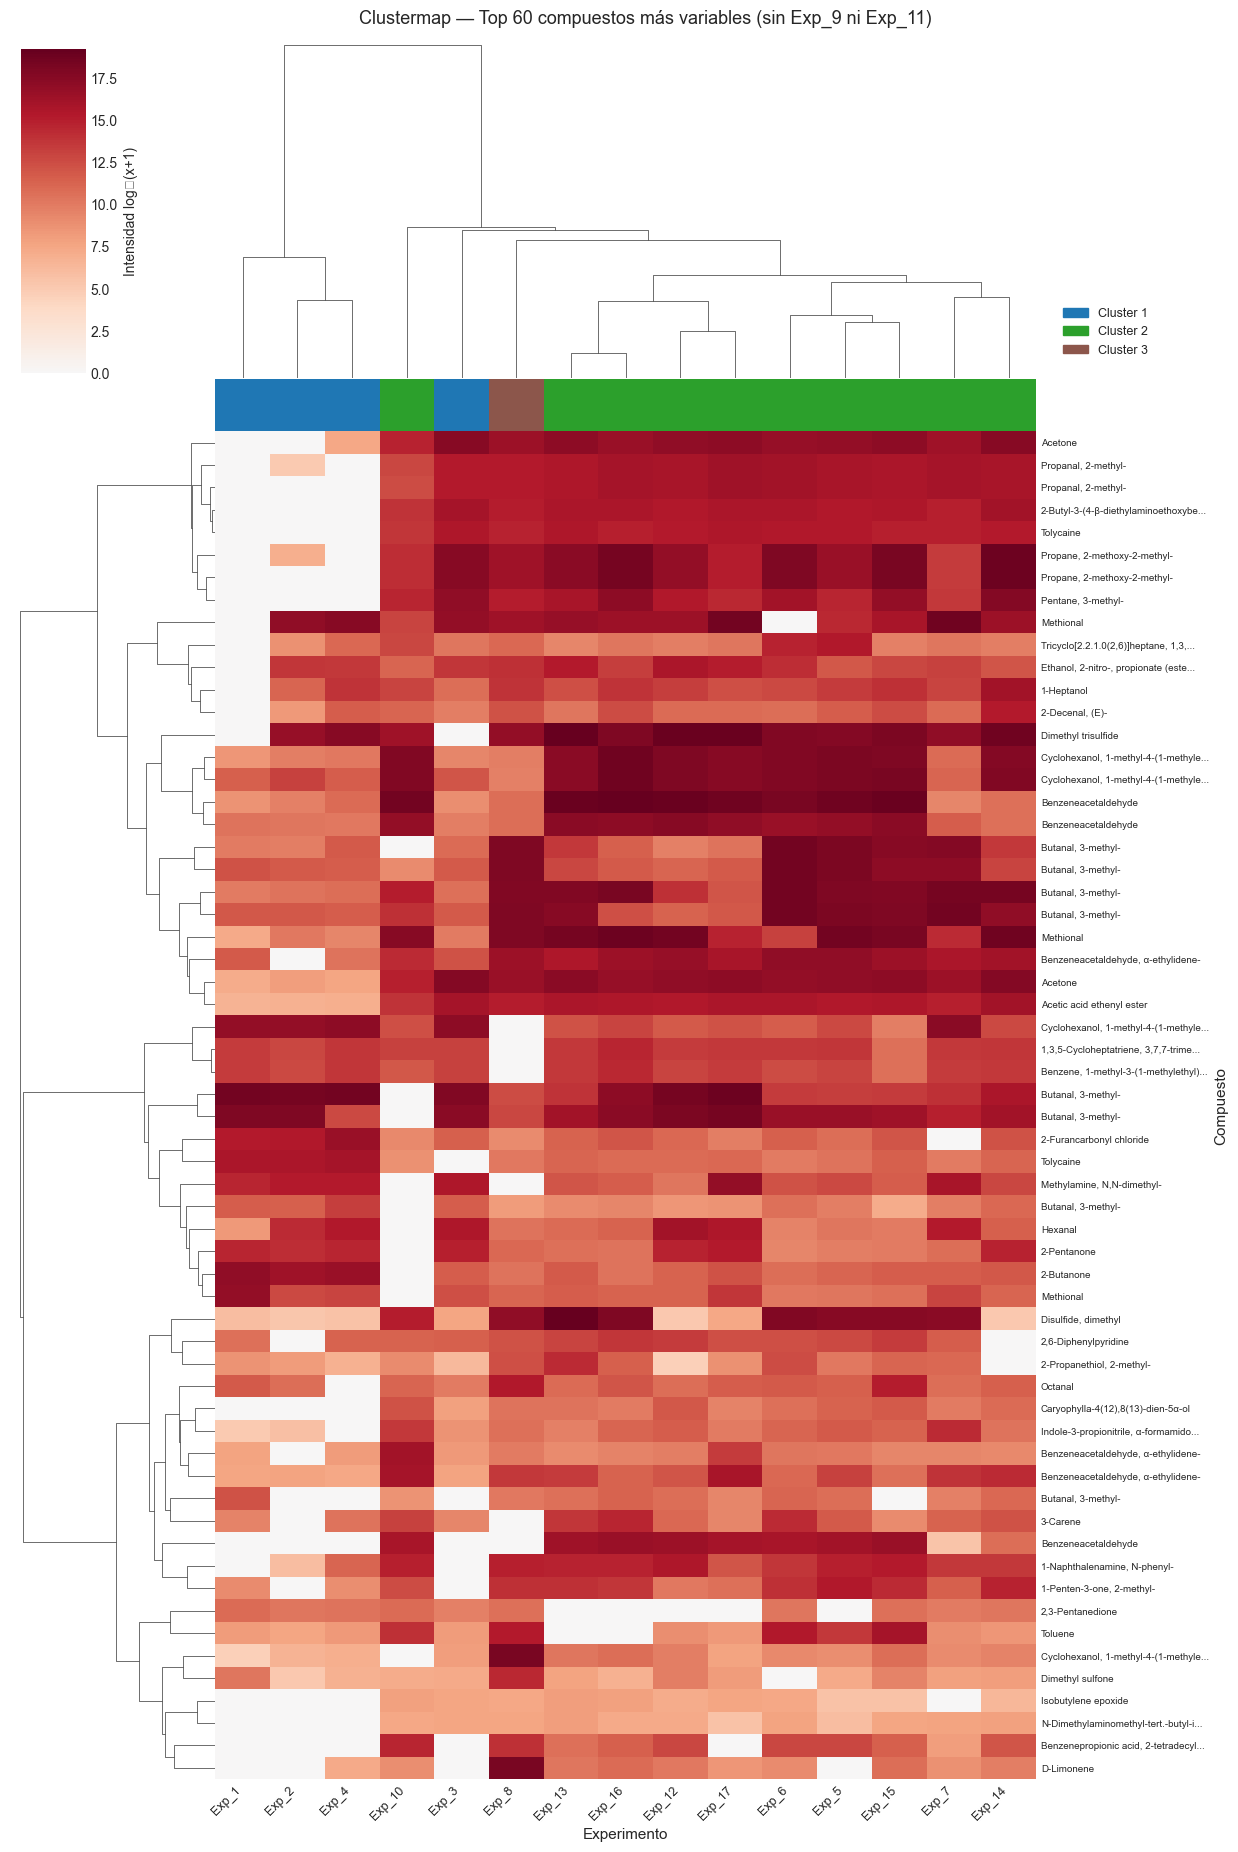

✓ Figura guardada: results/figures/05_clustermap_no_outlier.png


In [22]:
# ── Paso 5: Clustermap sin Exp_9 ni Exp_11 ────────────────────────────────────
# Top 60 compuestos más variables recalculados sobre el subconjunto sin ambos outliers,
# para que la selección refleje la variabilidad real del grupo principal.

variances_no_out_cpd = np.var(X_log2_no_out, axis=1)
top60_idx_no_out     = np.argsort(variances_no_out_cpd)[::-1][:60]

X_top60_no_out     = X_log2_no_out[top60_idx_no_out]   # 60 × 15
names_top60_no_out = compounds[top60_idx_no_out]
names_short_no_out = [n[:35] + '...' if len(n) > 35 else n for n in names_top60_no_out]

df_top60_no_out = pd.DataFrame(
    X_top60_no_out,
    index=names_short_no_out,
    columns=exp_labels_no_out
)

# Color de columna según cluster asignado
col_colors_no_out = [
    cluster_colors_no_out[
        exp_clusters_no_out_df.loc[
            exp_clusters_no_out_df['experiment'] == lab, 'cluster'
        ].values[0]
    ]
    for lab in exp_labels_no_out
]

g2 = sns.clustermap(
    df_top60_no_out,
    method='ward',
    metric='euclidean',
    cmap='RdBu_r',
    center=0,
    col_colors=col_colors_no_out,
    linewidths=0.0,
    figsize=(13, 18),
    xticklabels=True,
    yticklabels=True,
    cbar_kws={'label': 'Intensidad log₂(x+1)'}
)

g2.ax_heatmap.set_xlabel('Experimento', fontsize=11)
g2.ax_heatmap.set_ylabel('Compuesto', fontsize=11)
g2.ax_heatmap.set_xticklabels(
    g2.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=9
)
g2.ax_heatmap.set_yticklabels(g2.ax_heatmap.get_yticklabels(), fontsize=7)
g2.figure.suptitle(
    'Clustermap — Top 60 compuestos más variables (sin Exp_9 ni Exp_11)',
    fontsize=13, y=1.002
)

handles_cmap = [mpatches.Patch(color=cluster_colors_no_out[c], label=f'Cluster {c+1}')
                for c in range(K_NO_OUT)]
g2.ax_heatmap.legend(handles=handles_cmap, bbox_to_anchor=(1.15, 1.1),
                     loc='upper right', fontsize=9)

plt.savefig(FIGS / '05_clustermap_no_outlier.png', dpi=200, bbox_inches='tight')
plt.show()
print('✓ Figura guardada: results/figures/05_clustermap_no_outlier.png')

### Guardar resultados del clustering refinado (sin Exp_9 ni Exp_11)

In [ ]:
# ── Guardar CSV del clustering refinado (sin Exp_9 ni Exp_11) ─────────────────
# Se guarda como archivo separado: NO reemplaza experiment_clusters.csv original.

exp_clusters_no_out_df['is_outlier'] = False   # ninguno es outlier (ya se excluyeron)

out_path = DATA_PROC / 'experiment_clusters_no_outlier.csv'
exp_clusters_no_out_df.to_csv(out_path, index=False)

print('=' * 60)
print('ARCHIVOS GUARDADOS — CLUSTERING REFINADO')
print('=' * 60)
print()
print('✓ data/processed/experiment_clusters_no_outlier.csv')
print(f'  {len(exp_clusters_no_out_df)} experimentos × {exp_clusters_no_out_df.shape[1]} columnas')
print(f'  Experimentos excluidos: {OUTLIERS_NO}')
print()
print('Contenido:')
print(exp_clusters_no_out_df.to_string(index=False))
print()
print('Conteo por cluster:')
print(exp_clusters_no_out_df.groupby('cluster')['experiment'].apply(list).to_string())
print()
print('Figuras generadas en esta sección:')
print('  · 05_elbow_no_outlier.png')
print('  · 05_pca_no_outlier.png')
print('  · 05_clustermap_no_outlier.png')
print()
print('─' * 60)
print('ARCHIVOS TOTALES DEL NOTEBOOK 05')
print('─' * 60)
print('  data/processed/experiment_clusters.csv         ← clustering original (17 exp.)')
print('  data/processed/experiment_clusters_no_outlier.csv ← refinado (15 exp.)')
print('  data/processed/compound_clusters.csv           ← compuestos')

## Conclusiones

Tras excluir Exp_9 y Exp_11, el clustering revela una estructura interna más estable y menos condicionada por muestras extremas. Los grupos obtenidos sugieren que la variabilidad entre los experimentos restantes no es aleatoria, sino que responde a diferencias coordinadas en sus perfiles metabolómicos. En este contexto, los resultados del análisis refinado ofrecen una base más sólida para interpretar metabolitos diferenciales y explorar posibles patrones biológicos dentro del grupo principal de muestras.